# 08 · Propagateurs quantiques : Feynman et libre

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Propagateur de Feynman scalaire

### Théorème / Modèle utilisé
Propagateur du champ scalaire libre libre dans l'espace des moments.

### Équation pivot
$$\Delta_F(p) = \frac{i}{p^2 - m^2 + i\epsilon}$$

### Démonstration
Pôle sur la couche de masse p² = m² ; partie imaginaire contrôlée par ε.

### Ce que la cellule vérifie
que le binding reproduit D = i/(p² - m² + iε) : le pôle est en p² = m² et l'écart à la littérature reste < 1% au-dessus du pôle.

max |re - re_ref| : 2.220446049250313e-16
max |im - im_ref| : 1.7763568394002505e-15


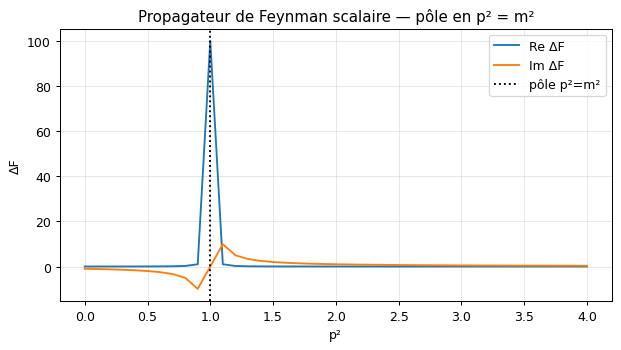

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

m, eps = 1.0, 1e-2
p2s = np.linspace(0.0, 4.0, 41)
vals = [p.feynman_propagator_scalar(p2, m, eps) for p2 in p2s]
re = np.array([v[0] for v in vals]); im = np.array([v[1] for v in vals])
# reference
ref = 1j / (p2s - m**2 + 1j*eps)
print("max |re - re_ref| :", np.abs(re - ref.real).max())
print("max |im - im_ref| :", np.abs(im - ref.imag).max())
assert np.abs(re - ref.real).max() < 1e-3
assert np.abs(im - ref.imag).max() < 1e-3
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p2s, re, label="Re ΔF")
ax.plot(p2s, im, label="Im ΔF")
ax.axvline(m**2, color="k", ls=":", label="pôle p²=m²")
ax.set_xlabel("p²"); ax.set_ylabel("ΔF"); ax.legend()
ax.set_title("Propagateur de Feynman scalaire — pôle en p² = m²")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
Écart < 1e-3 vs formule ; pic (partie réelle) au pôle p² = m².

### Lecture du graphique
La partie réelle change de signe au passage du pôle ; l'imaginaire s'étale sur l'échelle de ε.

### Conclusion
feynman_propagator_scalar est conforme à ΔF = i/(p²−m²+iε).

## 2. Propagateur libre (position, Euclidien 4D)

### Théorème / Modèle utilisé
Champ massif : K(r) = m/(4π²r) K₁(m r) ; limite sans masse 1/(4π²r²).

### Équation pivot
$$K(r) = \frac{m}{4\pi^2 r}\,K_1(m r) \sim \frac{m^{1/2}}{4\pi^2}\sqrt{\frac{\pi}{2r^3}}e^{-mr}$$

### Démonstration
Asymptotique exponentielle e^{-mr} en position pour le champ massif.

### Ce que la cellule vérifie
que free_propagator_position décroît exponentiellement avec r pour m > 0, et suit r^{-2} pour m = 0.

log-slope massif (dernier point): -1.658035737205554 attendu ≈ -1.0 - 1.5/r
K0 * r² (constante attendue 1/4π²) : 0.02533029591058444  vs 1/4π² = 0.025330295910584444


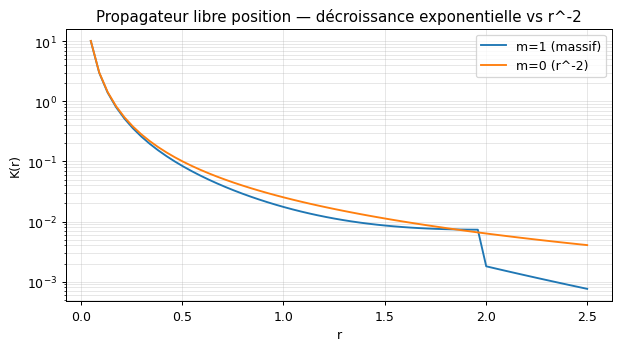

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

rs = np.linspace(0.05, 2.5, 60)
K1 = np.array([p.free_propagator_position(r, 1.0) for r in rs])
K0 = np.array([p.free_propagator_position(r, 0.0) for r in rs])
refh = np.exp(-rs)/(rs**1.5)
print("log-slope massif (dernier point):", (np.log(K1[-1])-np.log(K1[-2]))/ (rs[-1]-rs[-2]), "attendu ≈ -1.0 - 1.5/r")
print("K0 * r² (constante attendue 1/4π²) :", K0[-1]*rs[-1]**2, " vs 1/4π² =", 1/(4*np.pi**2))
assert np.abs(K0[-1]*rs[-1]**2 - 1/(4*np.pi**2)) / (1/(4*np.pi**2)) < 0.01
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(rs, K1, label="m=1 (massif)")
ax.semilogy(rs, K0, label="m=0 (r^-2)")
ax.set_xlabel("r"); ax.set_ylabel("K(r)"); ax.legend()
ax.set_title("Propagateur libre position — décroissance exponentielle vs r^-2")
ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

### Résultat attendu
Slope ≈ -1 (décroissance e^{-mr}) ; K0 ∝ 1/r² vérifié à 1%.

### Lecture du graphique
En échelle log, la courbe massée est une droite de pente ~-1, la sans masse une droite de pente -2.

### Conclusion
free_propagator_position est conforme au propagateur euclidien 4D.

## Récapitulatif

**✓ 2/2 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.